In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


In [8]:
# =========================
# 📂 PATHS (UNCHANGED)
# =========================
base_path = '/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Conjuctiva'

train_dr = base_path + '/Training'
valid_dr = base_path + '/Validation'

In [9]:

# =========================
# 🧠 IMPORT MOBILE NET
# =========================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# =========================
# 🖼️ IMAGE GENERATORS (CHANGED)
# =========================
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # 🔴 IMPORTANT CHANGE
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    train_dr,
    target_size=(224, 224),   # 🔴 CHANGED FROM 64 → 224
    batch_size=32,
    class_mode='binary'
)

valid_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    valid_dr,
    target_size=(224, 224),   # 🔴 CHANGED
    batch_size=32,
    class_mode='binary'
)


Found 8256 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


I0000 00:00:1777648896.583834      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777648896.590424      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,386,185 (9.10 MB)

...

Epoch 1/200


I0000 00:00:1777648906.493832     144 service.cc:152] XLA service 0x7c0d14002410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777648906.493874     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777648906.493879     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777648907.673633     144 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-01 15:21:57.288350: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 15:21:57.440858: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 15:21:57.576711: E external/local_xl

258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.5808 - loss: 0.6952

2026-05-01 15:24:26.076364: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-01 15:24:26.212931: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from inf to 0.58454, saving model to best_model_mobilenetv2.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 168s 579ms/step - accuracy: 0.5809 - loss: 0.6950 - val_accuracy: 0.7130 - val_loss: 0.5845
Epoch 2/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.6580 - loss: 0.6174
Epoch 2: val_loss improved from 0.58454 to 0.53825, saving model to best_model_mobilenetv2.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 95s 367ms/step - accuracy: 0.6580 - loss: 0.6173 - val_accuracy: 0.7260 - val_loss: 0.5382
Epoch 3/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.6974 - loss: 0.5743
Epoch 3: val_loss did not improve from 0.53825
258/258 ━━━━━━━━━━━━━━━━━━━━ 94s 364ms/step - accuracy: 0.6975 - loss: 0.5743 - val_accuracy: 0.7070 - val_loss: 0.5405
Epoch 4/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.7218 - loss: 0.5427
Epoch 4: val_loss improved from 0.53825 to 0.52993, saving model to best_model_mobilenetv2.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 97s 376m

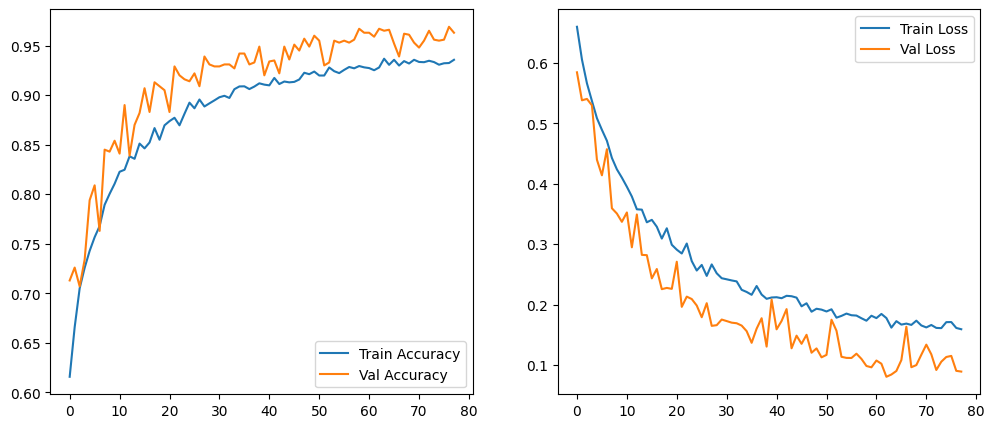

Found 1000 images belonging to 2 classes.
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step
[[487  13]
 [ 20 480]]
              precision    recall  f1-score   support

      Anemic       0.96      0.97      0.97       500
  Non-Anemic       0.97      0.96      0.97       500

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



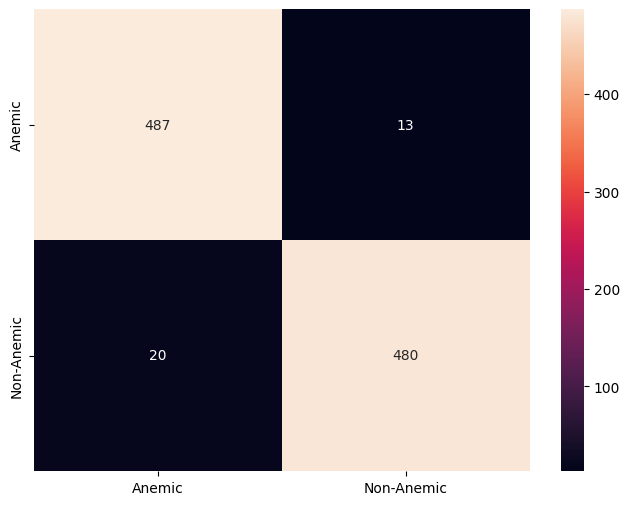

In [10]:

# =========================
# 🧱 MOBILE NET MODEL
# =========================
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# freeze base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(100, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=x)

model.summary()

# =========================
# ⚙️ COMPILE (UNCHANGED IDEA)
# =========================
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

# =========================
# 💾 CHECKPOINT (UNCHANGED)
# =========================
checkpoint = ModelCheckpoint(
    "best_model_mobilenetv2.keras",  # 🔴 FIXED: unique name so ResNet/DenseNet don't overwrite this
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(  # 🔴 ADDED: prevents overfitting over 200 epochs
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# =========================
# 🚀 TRAINING (UNCHANGED)
# =========================
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=200,
    callbacks=[checkpoint, early_stop]
)

# =========================
# 📊 PLOTS (UNCHANGED)
# =========================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()

plt.show()

# =========================
# 💾 LOAD BEST MODEL
# =========================
from tensorflow.keras.models import load_model
model = load_model("best_model_mobilenetv2.keras")  # 🔴 FIXED: matches checkpoint name

# =========================
# 🧪 EVALUATION (UNCHANGED LOGIC)
# =========================
eval_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    valid_dr,
    target_size=(224, 224),   # 🔴 FIXED
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

y_pred_probs = model.predict(eval_generator)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()
y_true = eval_generator.classes

from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(eval_generator.class_indices.keys())
))

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=list(eval_generator.class_indices.keys()),
            yticklabels=list(eval_generator.class_indices.keys()))
plt.show()

Found 8256 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,792,713 (90.76 MB)

 Trainable params: 205,001 (800.79 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.5726 - loss: 0.7575
Epoch 1: val_loss improved from inf to 0.59230, saving model to best_model_resnet50.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 120s 418ms/step - accuracy: 0.5727 - loss: 0.7572 - val_accuracy: 0.6820 - val_loss: 0.5923
Epoch 2/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.6615 - loss: 0.6128
Epoch 2: val_loss improved from 0.59230 to 0.53615, saving model to best_model_resnet50.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 100s 388ms/step - accuracy: 0.6615 - loss: 0.6128 - val_accuracy: 0.7360 - val_loss: 0.5362
Epoch 3/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.7013 - loss: 0.5709
Epoch 3: val_loss improved from 0.53615 to 0.52658, saving model to best_model_resnet50.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 100s 389ms/step - accuracy: 0.7013 - loss: 0.5709 - val_accuracy: 0.7510 - val_loss: 0.5266
Epoch 4/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.7213 - loss: 0.5390
Epo

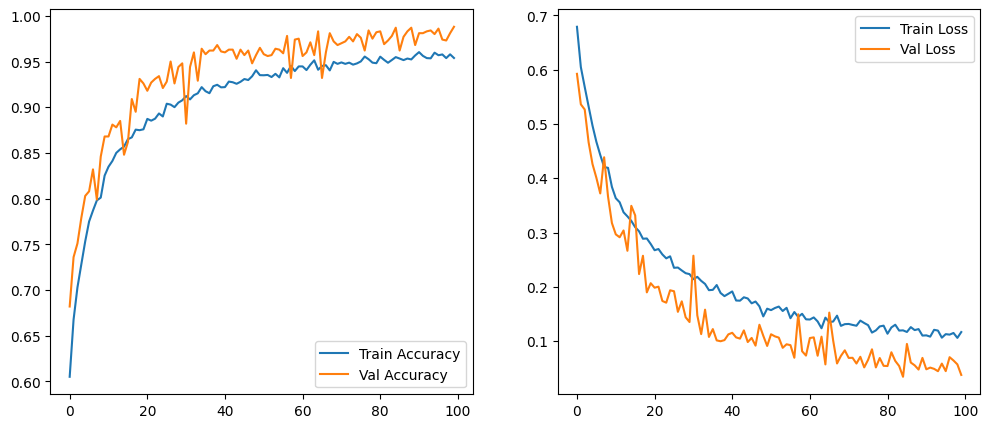

Found 1000 images belonging to 2 classes.
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step
[[494   6]
 [  7 493]]
              precision    recall  f1-score   support

      Anemic       0.99      0.99      0.99       500
  Non-Anemic       0.99      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



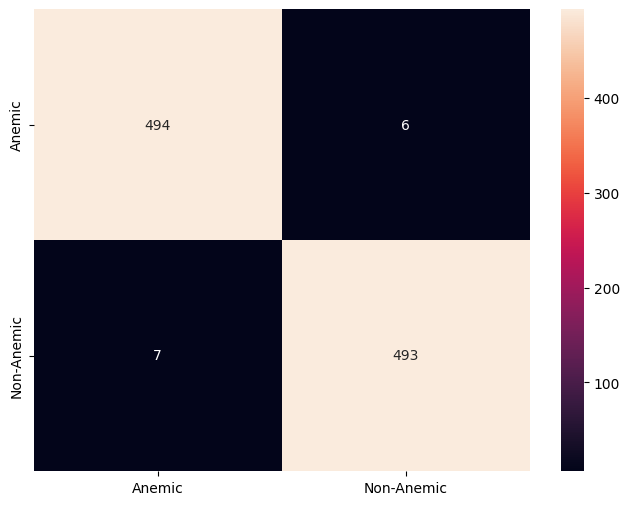

In [11]:
from sklearn.ensemble import RandomForestClassifier
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# =========================
# 📂 PATHS (UNCHANGED)
# =========================
base_path = '/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Conjuctiva'

train_dr = base_path + '/Training'
valid_dr = base_path + '/Validation'

# =========================
# 🧠 RESNET50 IMPORT
# =========================
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# =========================
# 🖼️ IMAGE GENERATORS (UPDATED PREPROCESS)
# =========================
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # 🔴 CHANGED FOR RESNET
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    train_dr,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

valid_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    valid_dr,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# =========================
# 🧱 RESNET50 MODEL
# =========================
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# freeze base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(100, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=x)

model.summary()

# =========================
# ⚙️ COMPILE
# =========================
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

# =========================
# 💾 CHECKPOINT
# =========================
checkpoint = ModelCheckpoint(
    "best_model_resnet50.keras",  # 🔴 FIXED: unique name
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(  # 🔴 ADDED: prevents overfitting over 200 epochs
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# =========================
# 🚀 TRAINING
# =========================
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=200,
    callbacks=[checkpoint, early_stop]
)

# =========================
# 📊 PLOTS
# =========================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()

plt.show()

# =========================
# 💾 LOAD BEST MODEL
# =========================
from tensorflow.keras.models import load_model
model = load_model("best_model_resnet50.keras")  # 🔴 FIXED: matches checkpoint name

# =========================
# 🧪 EVALUATION
# =========================
eval_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    valid_dr,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

y_pred_probs = model.predict(eval_generator)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()
y_true = eval_generator.classes

from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(eval_generator.class_indices.keys())
))

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=list(eval_generator.class_indices.keys()),
            yticklabels=list(eval_generator.class_indices.keys()))
plt.show()

Found 8256 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,514,185 (70.63 MB)

 Trainable params: 192,201 (750.79 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.5936 - loss: 0.6741
Epoch 1: val_loss improved from inf to 0.58186, saving model to best_model_densenet201.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 186s 553ms/step - accuracy: 0.5937 - loss: 0.6740 - val_accuracy: 0.6840 - val_loss: 0.5819
Epoch 2/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.6637 - loss: 0.6097
Epoch 2: val_loss improved from 0.58186 to 0.51928, saving model to best_model_densenet201.keras
258/258 ━━━━━━━━━━━━━━━━━━━━ 109s 421ms/step - accuracy: 0.6637 - loss: 0.6096 - val_accuracy: 0.7490 - val_loss: 0.5193
Epoch 3/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.7029 - loss: 0.5615
Epoch 3: val_loss did not improve from 0.51928
258/258 ━━━━━━━━━━━━━━━━━━━━ 103s 397ms/step - accuracy: 0.7029 - loss: 0.5614 - val_accuracy: 0.6450 - val_loss: 0.6178
Epoch 4/200
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.7188 - loss: 0.5415
Epoch 4: val_loss improved from 0.51928 to 0

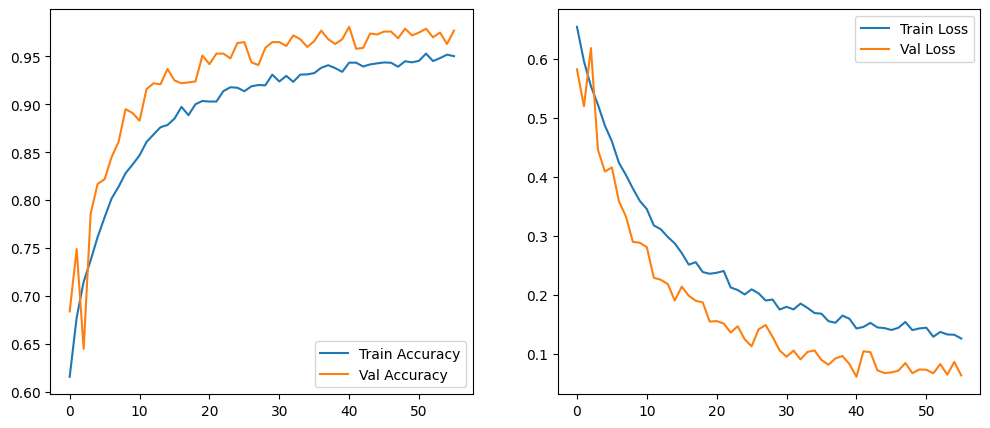

Found 1000 images belonging to 2 classes.
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 774ms/step
[[493   7]
 [ 12 488]]
              precision    recall  f1-score   support

      Anemic       0.98      0.99      0.98       500
  Non-Anemic       0.99      0.98      0.98       500

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



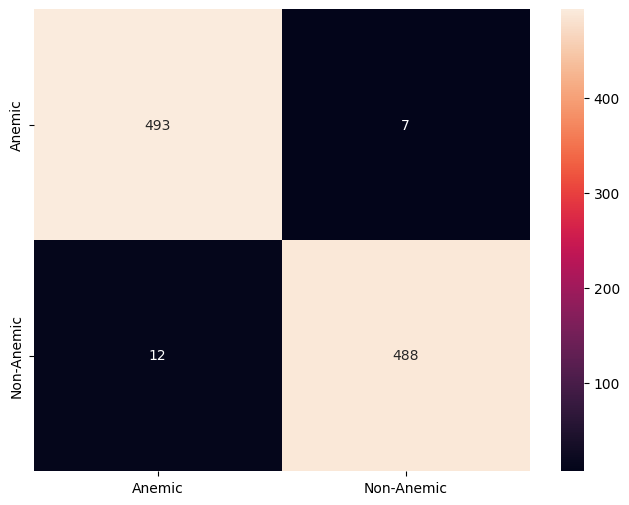

In [12]:

from sklearn.ensemble import RandomForestClassifier
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# =========================
# 📂 PATHS (UNCHANGED)
# =========================
base_path = '/kaggle/input/datasets/t2obd1a1253kmit/clean-augmented-anemia-dataset/New_Augmented_Anemia_Dataset/Conjuctiva'

train_dr = base_path + '/Training'
valid_dr = base_path + '/Validation'

# =========================
# 🟣 DENSENET201 IMPORT
# =========================
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input

# =========================
# 🖼️ IMAGE GENERATORS
# =========================
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    train_dr,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

valid_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    valid_dr,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# =========================
# 🧱 DENSENET201 MODEL
# =========================
base_model = DenseNet201(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# freeze base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(100, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=x)

model.summary()

# =========================
# ⚙️ COMPILE
# =========================
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

# =========================
# 💾 CHECKPOINT
# =========================
checkpoint = ModelCheckpoint(
    "best_model_densenet201.keras",  # 🔴 FIXED: unique name
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(  # 🔴 ADDED: prevents overfitting over 200 epochs
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# =========================
# 🚀 TRAINING
# =========================
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=200,
    callbacks=[checkpoint, early_stop]
)

# =========================
# 📊 PLOTS
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()

plt.show()

# =========================
# 💾 LOAD BEST MODEL
# =========================
from tensorflow.keras.models import load_model
model = load_model("best_model_densenet201.keras")  # 🔴 FIXED: matches checkpoint name

# =========================
# 🧪 EVALUATION
# =========================
eval_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    valid_dr,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

y_pred_probs = model.predict(eval_generator)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()
y_true = eval_generator.classes

from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(eval_generator.class_indices.keys())
))

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=list(eval_generator.class_indices.keys()),
            yticklabels=list(eval_generator.class_indices.keys()))
plt.show()